# Altitude Comparison: IMU vs UHI (Highlight Interval Only)

This notebook extracts and plots the altitude comparison between IMU and UHI for the specific time interval:
- **Start**: 2024-10-29 12:06:38 UTC
- **End**: 2024-10-29 12:07:31 UTC

The plot shows:
- **Blue line**: IMU altitude from navigation data
- **Orange line**: UHI altitude (minimum range from camera rays to MBES seafloor)

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Add paths
gref4hsi_root = Path.cwd().parent.parent
mjosa_code_root = Path.cwd().parent
sys.path.insert(0, str(gref4hsi_root / "gref4hsi" / "final_act" / "utils"))
sys.path.insert(0, str(mjosa_code_root))

from utils.common import config
from gref_pipeline import utils

In [2]:
# Highlight interval (UNSHIFTED)
HIGHLIGHT_START = datetime.fromisoformat("2024-10-29T12:06:38+00:00")
HIGHLIGHT_END = datetime.fromisoformat("2024-10-29T12:07:31+00:00")

print(f"Time interval: {HIGHLIGHT_START} to {HIGHLIGHT_END}")
print(f"Duration: {(HIGHLIGHT_END - HIGHLIGHT_START).total_seconds():.1f} seconds")

Time interval: 2024-10-29 12:06:38+00:00 to 2024-10-29 12:07:31+00:00
Duration: 53.0 seconds


In [3]:
# Helper functions from create_sim.py


def _extract_rpy(nav_like):
    if isinstance(nav_like, dict):
        cols = nav_like.keys()
        get = lambda k: np.asarray(nav_like[k])
    else:
        cols = nav_like.columns
        get = lambda k: nav_like[k].to_numpy()
    for r, p, y in [
        ("roll", "pitch", "yaw"),
        ("roll_deg", "pitch_deg", "yaw_deg"),
        ("phi", "theta", "psi"),
    ]:
        if r in cols and p in cols and y in cols:
            return get(r), get(p), get(y)
    raise KeyError("roll/pitch/yaw columns not found.")


def _body_to_enu_rotation(roll_rad, pitch_rad, yaw_deg):
    yaw_val = np.deg2rad(90.0 - yaw_deg)
    cr, sr = np.cos(roll_rad), np.sin(roll_rad)
    cp, sp = np.cos(pitch_rad), np.sin(pitch_rad)
    cy, sy = np.cos(yaw_val), np.sin(yaw_val)
    Rz = np.array([[cy, -sy, 0.0], [sy, cy, 0.0], [0.0, 0.0, 1.0]])
    Ry = np.array([[cp, 0.0, sp], [0.0, 1.0, 0.0], [-sp, 0.0, cp]])
    Rx = np.array([[1.0, 0.0, 0.0], [0.0, cr, -sr], [0.0, sr, cr]])
    return Rz @ Ry @ Rx


def _rc_from_xy(transform, x, y):
    a, b, c, d, e, f = (
        transform.a,
        transform.b,
        transform.c,
        transform.d,
        transform.e,
        transform.f,
    )
    X = x - (c + 0.5 * (a + b))
    Y = y - (f + 0.5 * (d + e))
    M = np.array([[a, b], [d, e]], dtype=float)
    try:
        col_f, row_f = np.linalg.solve(M, np.array([X, Y]))
    except np.linalg.LinAlgError:
        col_f = X / (a if a != 0 else 1.0)
        row_f = Y / (e if e != 0 else -1.0)
    return float(row_f), float(col_f)


def _bilinear_z_at(x, y, dem, transform):
    row_f, col_f = _rc_from_xy(transform, x, y)
    r0 = int(np.floor(row_f))
    c0 = int(np.floor(col_f))
    r1 = r0 + 1
    c1 = c0 + 1
    h, w = dem.shape
    if r0 < 0 or c0 < 0 or r1 >= h or c1 >= w:
        return np.nan
    z00, z01 = dem[r0, c0], dem[r0, c1]
    z10, z11 = dem[r1, c0], dem[r1, c1]
    if not (
        np.isfinite(z00) and np.isfinite(z01) and np.isfinite(z10) and np.isfinite(z11)
    ):
        return np.nan
    fr = row_f - r0
    fc = col_f - c0
    z0 = z00 * (1 - fc) + z01 * fc
    z1 = z10 * (1 - fc) + z11 * fc
    return z0 * (1 - fr) + z1 * fr


def _intersect_ray_dem(
    cam_xyz, d_world, dem, transform, t_max=60.0, step=0.5, bisect_iters=8
):
    cx, cy, cz = cam_xyz
    dx, dy, dz = d_world
    if dz >= 0:
        return np.nan
    z_surf0 = _bilinear_z_at(cx, cy, dem, transform)
    if not np.isfinite(z_surf0):
        return np.nan
    f_prev = cz - z_surf0
    if f_prev <= 0:
        return 0.0
    t = step
    while t <= t_max:
        x = cx + dx * t
        y = cy + dy * t
        z = cz + dz * t
        z_surf = _bilinear_z_at(x, y, dem, transform)
        if not np.isfinite(z_surf):
            t += step
            continue
        f = z - z_surf
        if f <= 0.0:
            lo = t - step
            hi = t
            for _ in range(bisect_iters):
                mid = 0.5 * (lo + hi)
                xm = cx + dx * mid
                ym = cy + dy * mid
                zm = cz + dz * mid
                zsm = _bilinear_z_at(xm, ym, dem, transform)
                if not np.isfinite(zsm):
                    hi = mid
                    continue
                fm = zm - zsm
                if fm > 0:
                    lo = mid
                else:
                    hi = mid
            return 0.5 * (lo + hi)
        t += step
    return np.nan


print("✅ Helper functions loaded")

✅ Helper functions loaded


In [4]:
# Load navigation data
nav_df = utils.load_csv_navigation(config.NAV_CSV, config.CSV_COLUMNS)
print(f"Loaded {len(nav_df)} navigation records")

# Load H5 timestamps
h5_folder = Path(config.H5_FOLDER)
h5_files = sorted(h5_folder.glob("*.h5"))
print(f"Found {len(h5_files)} H5 files")

offset = float(config.TIME_OFFSET_SEC)
all_timestamps = []
for p in h5_files:
    ts = utils.load_h5_timestamps(str(p))
    all_timestamps.append(ts)

timestamps = np.concatenate(all_timestamps)
print(f"Total frames: {len(timestamps)}")

Loaded 234151 navigation records from e:\mjosa_complete\data\processed\navigation\nav_data_merged.csv
Time range: 1730196822.84 to 1730207761.97
Loaded 234151 navigation records
Found 6 H5 files
Loaded 1333 timestamps from rad_uhi_20241029_115057_1.h5
  Dataset path: processed/radiance/timestamp
  Time range: 1730202657.31 to 1730202724.05
Loaded 1946 timestamps from rad_uhi_20241029_115057_2.h5
  Dataset path: processed/radiance/timestamp
  Time range: 1730202724.10 to 1730202821.56
Loaded 2227 timestamps from rad_uhi_20241029_115057_3.h5
  Dataset path: processed/radiance/timestamp
  Time range: 1730202821.61 to 1730202933.14
Loaded 2463 timestamps from rad_uhi_20241029_115057_4.h5
  Dataset path: processed/radiance/timestamp
  Time range: 1730202933.19 to 1730203056.55
Loaded 2462 timestamps from rad_uhi_20241029_115057_5.h5
  Dataset path: processed/radiance/timestamp
  Time range: 1730203056.60 to 1730203179.91
Loaded 155 timestamps from rad_uhi_20241029_115057_6.h5
  Dataset path

In [5]:
# Interpolate navigation for all timestamps
interp_nav = utils.interpolate_navigation(nav_df, timestamps, time_offset=offset)

# Get altitude - CRITICAL: Check which field exists
print(f"Available fields in interp_nav: {list(interp_nav.keys())}")

if "altitude" in interp_nav:
    alt_imu = np.asarray(interp_nav["altitude"])
    print("✅ Using 'altitude' field")
elif "altitude_m" in interp_nav:
    alt_imu = np.asarray(interp_nav["altitude_m"])
    print("✅ Using 'altitude_m' field")
elif "depth" in interp_nav:
    alt_imu = -np.asarray(interp_nav["depth"])
    print("⚠️ Using negative 'depth' as altitude (THIS MAY BE WRONG!)")
else:
    raise ValueError("No altitude data found")

print(f"Altitude range: {np.nanmin(alt_imu):.2f} to {np.nanmax(alt_imu):.2f} m")
print(f"Altitude mean: {np.nanmean(alt_imu):.2f} m")

# Convert to UTM
xe, ye, ze = utils.geographic_to_ecef(
    interp_nav["longitude"],
    interp_nav["latitude"],
    -interp_nav["depth"],
    epsg_geo=config.EPSG_GEOGRAPHIC,
    epsg_ecef=config.EPSG_ECEF,
)
x_imu, y_imu, z_imu = utils.ecef_to_utm(
    xe, ye, ze, epsg_utm=config.EPSG_MBES, epsg_ecef=config.EPSG_ECEF
)

print(f"z_imu (elevation) range: {np.nanmin(z_imu):.2f} to {np.nanmax(z_imu):.2f} m")

# Get orientation
roll, pitch, yaw = _extract_rpy(interp_nav)

# Lookup timestamps (with offset)
lookup_ts = timestamps + offset

print(f"Interpolated {len(alt_imu)} frames")

Interpolated navigation for 10586 HSI frames
Available fields in interp_nav: ['latitude', 'longitude', 'depth', 'roll', 'pitch', 'yaw', 'altitude']
✅ Using 'altitude' field
Altitude range: 2.87 to 3.05 m
Altitude mean: 2.96 m
z_imu (elevation) range: -132.61 to -108.44 m
Interpolated 10586 frames


In [6]:
# Filter to highlight interval
t_dt = np.array([datetime.fromtimestamp(float(t), tz=timezone.utc) for t in lookup_ts])

mask = (t_dt >= HIGHLIGHT_START) & (t_dt <= HIGHLIGHT_END)
n_highlight = mask.sum()

print(f"Frames in highlight interval: {n_highlight}")
print(f"First frame: {t_dt[mask][0]}")
print(f"Last frame: {t_dt[mask][-1]}")
print(
    f"Highlight altitude range: {np.nanmin(alt_imu[mask]):.2f} to {np.nanmax(alt_imu[mask]):.2f} m"
)

# Extract highlight data
t_dt_hl = t_dt[mask]
alt_imu_hl = alt_imu[mask]
x_imu_hl = x_imu[mask]
y_imu_hl = y_imu[mask]
z_imu_hl = z_imu[mask]
roll_hl = roll[mask]
pitch_hl = pitch[mask]
yaw_hl = yaw[mask]

Frames in highlight interval: 1058
First frame: 2024-10-29 12:06:38.024799+00:00
Last frame: 2024-10-29 12:07:30.986435+00:00
Highlight altitude range: 2.90 to 3.00 m


In [7]:
# Load MBES DEM
with rasterio.open(config.MBES_GEOTIFF_057) as src:
    src_epsg = src.crs.to_epsg() if src.crs else None
    if src_epsg == config.EPSG_MBES:
        mbes_arr = src.read(1, masked=True).filled(np.nan)
        mbes_transform = src.transform
    else:
        dst_crs = rasterio.crs.CRS.from_epsg(config.EPSG_MBES)
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        mbes_arr = np.full((height, width), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=mbes_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
        mbes_transform = transform

print(f"MBES DEM loaded: {mbes_arr.shape}")

MBES DEM loaded: (5249, 1408)


In [8]:
# Load camera calibration and compute UHI altitude
camera_calib = utils.load_camera_calibration(config.CAMERA_CALIB_XML)
R_B_FROM_CAM = np.array(config.ROTATION_HSI_TO_BODY, dtype=float)
CAMERA_FWD_OFFSET_M = 2.5

W = int(camera_calib["w"])
rays_cam = utils.build_ray_directions(camera_calib, W)

# Sample rays (use 31 for speed)
n_rays_sample = 31
sel = np.linspace(0, W - 1, n_rays_sample, dtype=int)
rays_cam = rays_cam[sel, :]
rays_cam = rays_cam / np.linalg.norm(rays_cam, axis=1, keepdims=True)

print(
    f"Computing UHI altitude for {n_highlight} frames (using {n_rays_sample} rays per frame)..."
)
print("This may take a minute...")

uhi_alt_hl = np.full(n_highlight, np.nan, dtype=float)

for i in range(n_highlight):
    if i % 50 == 0:
        print(f"  Processing frame {i}/{n_highlight}...")

    # Body to world rotation
    R_bw = _body_to_enu_rotation(
        np.deg2rad(roll_hl[i]), np.deg2rad(pitch_hl[i]), yaw_hl[i]
    )

    # Camera position in world
    cam_off_world = R_bw @ np.array([CAMERA_FWD_OFFSET_M, 0.0, 0.0])
    cam_xyz = np.array([x_imu_hl[i], y_imu_hl[i], z_imu_hl[i]]) + cam_off_world

    # Camera to world rotation
    R_wc = R_bw @ R_B_FROM_CAM
    d_world = (R_wc @ rays_cam.T).T
    d_world = d_world / np.linalg.norm(d_world, axis=1, keepdims=True)

    # Intersect rays with DEM
    ranges = []
    for d in d_world:
        r = _intersect_ray_dem(
            cam_xyz, d, mbes_arr, mbes_transform, t_max=60.0, step=0.5, bisect_iters=8
        )
        if np.isfinite(r):
            ranges.append(r)

    if ranges:
        uhi_alt_hl[i] = np.nanmin(ranges)

print(f"✅ UHI altitude computed ({np.isfinite(uhi_alt_hl).sum()}/{n_highlight} valid)")

Computing UHI altitude for 1058 frames (using 31 rays per frame)...
This may take a minute...
  Processing frame 0/1058...
  Processing frame 50/1058...
  Processing frame 100/1058...
  Processing frame 150/1058...
  Processing frame 200/1058...
  Processing frame 250/1058...
  Processing frame 300/1058...
  Processing frame 350/1058...
  Processing frame 400/1058...
  Processing frame 450/1058...
  Processing frame 500/1058...
  Processing frame 550/1058...
  Processing frame 600/1058...
  Processing frame 650/1058...
  Processing frame 700/1058...
  Processing frame 750/1058...
  Processing frame 800/1058...
  Processing frame 850/1058...
  Processing frame 900/1058...
  Processing frame 950/1058...
  Processing frame 1000/1058...
  Processing frame 1050/1058...
✅ UHI altitude computed (1058/1058 valid)


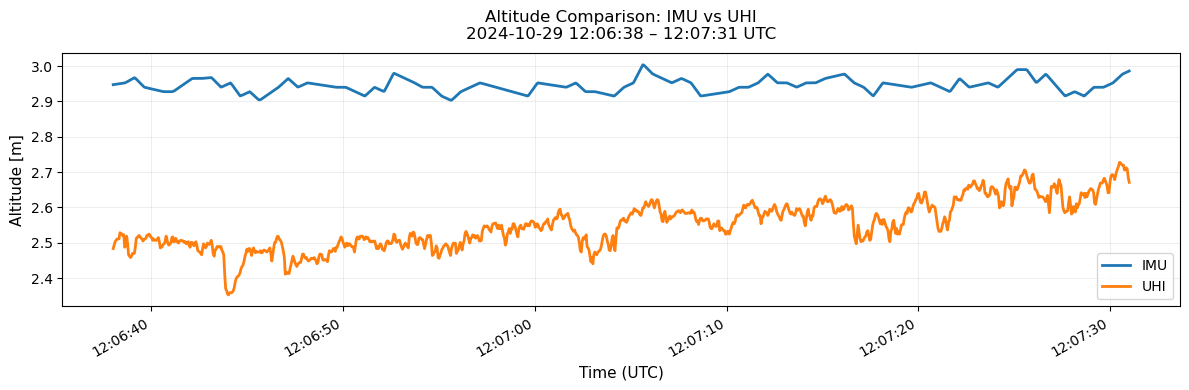

In [9]:
# Plot altitude comparison (highlight interval only)
fig, ax = plt.subplots(figsize=(12, 4))

IMU_COLOR = "#1f77b4"  # blue
UHI_COLOR = "#ff7f0e"  # orange

(imu_line,) = ax.plot(
    t_dt_hl, alt_imu_hl, lw=2.0, color=IMU_COLOR, label="IMU", zorder=2
)
(uhi_line,) = ax.plot(
    t_dt_hl, uhi_alt_hl, lw=2.0, color=UHI_COLOR, label="UHI", zorder=2
)

ax.set_title(
    "Altitude Comparison: IMU vs UHI\n2024-10-29 12:06:38 – 12:07:31 UTC",
    fontsize=12,
    pad=10,
)
ax.set_xlabel("Time (UTC)", fontsize=11)
ax.set_ylabel("Altitude [m]", fontsize=11)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(handles=[imu_line, uhi_line], labels=["IMU", "UHI"], loc="best", fontsize=10)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [10]:
# Save highlight interval plot as PDF (no dpi)
# output_path = Path(
#     "../images_for_publication/stability/altitude_comparison_highlight.pdf"
# )
# output_path.parent.mkdir(parents=True, exist_ok=True)

# fig.savefig(output_path, bbox_inches="tight", pad_inches=0.1)
# print(f"✅ Saved: {output_path}")

---
## Full Mission Plot (Original)

This shows the complete altitude comparison across the entire mission, matching the plot from create_sim.py

In [11]:
# Compute UHI altitude for FULL mission (for comparison plot)
print(f"Computing UHI altitude for FULL mission ({len(timestamps)} frames)...")
print("This will take several minutes...")

uhi_alt_full = np.full(len(timestamps), np.nan, dtype=float)

for i in range(len(timestamps)):
    if i % 100 == 0:
        print(f"  Processing frame {i}/{len(timestamps)}...")

    # Body to world rotation
    R_bw = _body_to_enu_rotation(np.deg2rad(roll[i]), np.deg2rad(pitch[i]), yaw[i])

    # Camera position in world
    cam_off_world = R_bw @ np.array([CAMERA_FWD_OFFSET_M, 0.0, 0.0])
    cam_xyz = np.array([x_imu[i], y_imu[i], z_imu[i]]) + cam_off_world

    # Camera to world rotation
    R_wc = R_bw @ R_B_FROM_CAM
    d_world = (R_wc @ rays_cam.T).T
    d_world = d_world / np.linalg.norm(d_world, axis=1, keepdims=True)

    # Intersect rays with DEM
    ranges = []
    for d in d_world:
        r = _intersect_ray_dem(
            cam_xyz, d, mbes_arr, mbes_transform, t_max=60.0, step=0.5, bisect_iters=8
        )
        if np.isfinite(r):
            ranges.append(r)

    if ranges:
        uhi_alt_full[i] = np.nanmin(ranges)

print(
    f"✅ UHI altitude computed for full mission ({np.isfinite(uhi_alt_full).sum()}/{len(timestamps)} valid)"
)
print(
    f"UHI altitude range: {np.nanmin(uhi_alt_full):.2f} to {np.nanmax(uhi_alt_full):.2f} m"
)

Computing UHI altitude for FULL mission (10586 frames)...
This will take several minutes...
  Processing frame 0/10586...
  Processing frame 100/10586...
  Processing frame 200/10586...
  Processing frame 300/10586...
  Processing frame 400/10586...
  Processing frame 500/10586...
  Processing frame 600/10586...
  Processing frame 700/10586...
  Processing frame 800/10586...
  Processing frame 900/10586...
  Processing frame 1000/10586...
  Processing frame 1100/10586...
  Processing frame 1200/10586...
  Processing frame 1300/10586...
  Processing frame 1400/10586...
  Processing frame 1500/10586...
  Processing frame 1600/10586...
  Processing frame 1700/10586...
  Processing frame 1800/10586...
  Processing frame 1900/10586...
  Processing frame 2000/10586...
  Processing frame 2100/10586...
  Processing frame 2200/10586...
  Processing frame 2300/10586...
  Processing frame 2400/10586...
  Processing frame 2500/10586...
  Processing frame 2600/10586...
  Processing frame 2700/10586

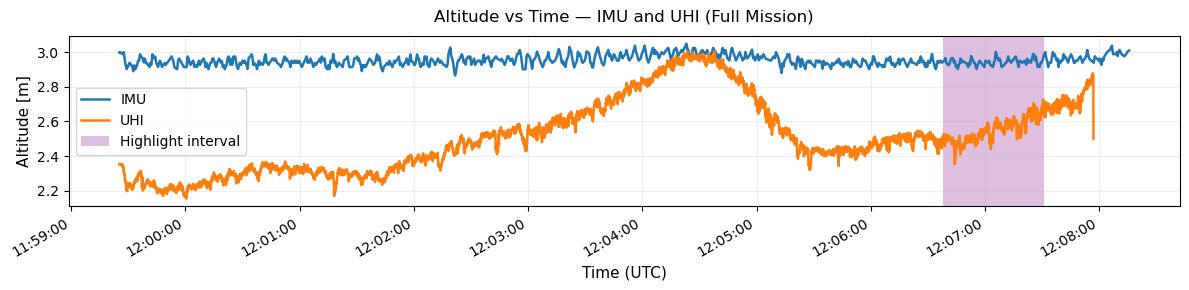

In [12]:
# Plot full mission altitude comparison (like in create_sim.py)
fig_full, ax_full = plt.subplots(figsize=(12, 3))

IMU_COLOR = "#1f77b4"  # blue
UHI_COLOR = "#ff7f0e"  # orange
HIGHLIGHT_COLOR = "purple"

# Full mission data
(imu_line_full,) = ax_full.plot(
    t_dt, alt_imu, lw=1.8, color=IMU_COLOR, label="IMU", zorder=2
)
(uhi_line_full,) = ax_full.plot(
    t_dt, uhi_alt_full, lw=1.8, color=UHI_COLOR, label="UHI", zorder=2
)

# Add purple highlight region
ax_full.axvspan(
    HIGHLIGHT_START,
    HIGHLIGHT_END,
    facecolor=HIGHLIGHT_COLOR,
    alpha=0.25,
    edgecolor="none",
    label="Highlight interval",
)

ax_full.set_title("Altitude vs Time — IMU and UHI (Full Mission)", fontsize=12, pad=10)
ax_full.set_xlabel("Time (UTC)", fontsize=11)
ax_full.set_ylabel("Altitude [m]", fontsize=11)
ax_full.grid(True, alpha=0.3, linewidth=0.5)
ax_full.legend(loc="best", fontsize=10)

ax_full.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig_full.autofmt_xdate()
plt.tight_layout()

plt.show()

In [13]:
# Save full mission plot as PDF
# output_path_full = Path(
#     "../images_for_publication/stability/altitude_comparison_full.pdf"
# )
# output_path_full.parent.mkdir(parents=True, exist_ok=True)

# fig_full.savefig(output_path_full, bbox_inches="tight", pad_inches=0.1)
# print(f"✅ Saved: {output_path_full}")

In [14]:
# Save highlight interval plot as PDF
# output_path = Path("../images_for_publication/altitude_comparison_highlight.pdf")
# output_path.parent.mkdir(parents=True, exist_ok=True)

# fig.savefig(output_path, bbox_inches="tight", pad_inches=0.1)
# print(f"✅ Saved: {output_path}")

---
## Stability Plots for Publication

Generate attitude and DVL velocity plots for the highlight segment

In [15]:
# Load DVL data from database
sys.path.append(str(mjosa_code_root / "external_libs" / "eelume_pypost"))
from Eelume import PyPost as pp

# Convert highlight times to Unix timestamps
t_start_unix = HIGHLIGHT_START.timestamp()
t_end_unix = HIGHLIGHT_END.timestamp()

print(f"Loading DVL data for highlight interval...")
print(f"Start: {HIGHLIGHT_START}")
print(f"End: {HIGHLIGHT_END}")

db = pp.DatabaseHandler(config.DB_PATH)

sig_x = db.get_signal(
    "/sensors/dvl/velocity/D__x",
    start_time=t_start_unix,
    end_time=t_end_unix,
    reset_time_stamp_to_zero=False,
)
sig_y = db.get_signal(
    "/sensors/dvl/velocity/D__y",
    start_time=t_start_unix,
    end_time=t_end_unix,
    reset_time_stamp_to_zero=False,
)
sig_z = db.get_signal(
    "/sensors/dvl/velocity/D__z",
    start_time=t_start_unix,
    end_time=t_end_unix,
    reset_time_stamp_to_zero=False,
)

# Convert DVL timestamps to UTC datetime
times_dvl_x = [datetime.fromtimestamp(ts, tz=timezone.utc) for ts in sig_x.axis]
times_dvl_y = [datetime.fromtimestamp(ts, tz=timezone.utc) for ts in sig_y.axis]
times_dvl_z = [datetime.fromtimestamp(ts, tz=timezone.utc) for ts in sig_z.axis]

print(f"✅ Loaded DVL data:")
print(f"  D__x: {len(sig_x.data)} samples")
print(f"  D__y: {len(sig_y.data)} samples")
print(f"  D__z: {len(sig_z.data)} samples")

Loading DVL data for highlight interval...
Start: 2024-10-29 12:06:38+00:00
End: 2024-10-29 12:07:31+00:00
✅ Loaded DVL data:
  D__x: 104 samples
  D__y: 104 samples
  D__z: 106 samples


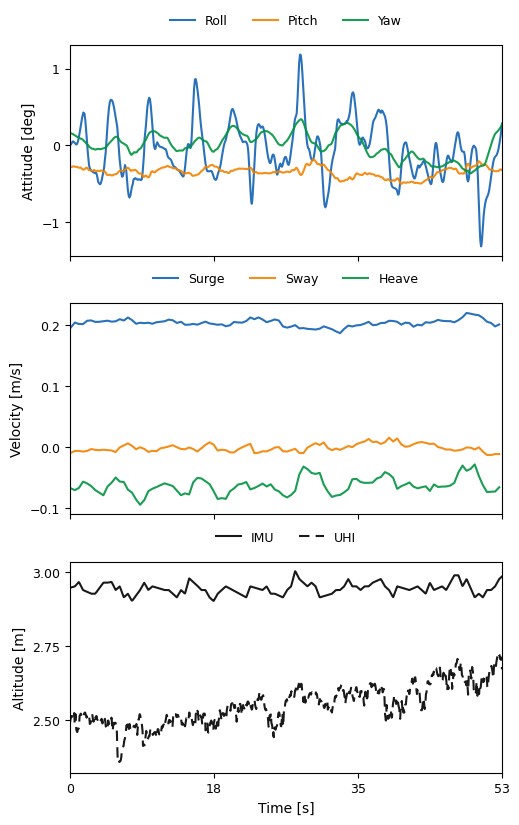


📊 Attitude Statistics (Highlight Segment):
  Roll:  μ=-0.07°, σ=0.37°
  Pitch: μ=-0.35°, σ=0.06°
  Yaw (centered):   μ=-0.00°, σ=0.16°
  Yaw (original):   μ=180.03°

📊 DVL Statistics (Highlight Segment):
  Surge (D__x): μ=0.203 m/s, σ=0.006 m/s
  Sway (D__y):  μ=-0.002 m/s, σ=0.006 m/s
  Heave (D__z): μ=-0.063 m/s, σ=0.013 m/s

📊 Altitude Statistics (Highlight Segment):
  IMU: μ=2.945 m, σ=0.018 m
  UHI: μ=2.550 m, σ=0.068 m


In [51]:
def plot_stability_figure(
    # Data inputs
    t_dt_hl,
    roll_hl,
    pitch_hl,
    yaw_hl,
    times_dvl_x,
    times_dvl_y,
    times_dvl_z,
    sig_x_data,
    sig_y_data,
    sig_z_data,
    alt_imu_hl,
    uhi_alt_hl,
    # ADJUSTABLE PARAMETERS
    fig_width=5.0,  # Figure width in inches
    fig_height=5.5,  # Figure height in inches (INCREASE THIS to make plots bigger)
    legend_y_offset=1.25,  # Legend position above subplot (lower = closer)
    subplot_vertical_spacing=0.3,  # Space between subplots (h_pad)
    n_yticks_attitude=3,  # Number of Y-axis ticks for attitude
    n_yticks_velocity=4,  # Number of Y-axis ticks for velocity
    n_yticks_altitude=3,  # Number of Y-axis ticks for altitude
    n_xticks=4,  # Number of X-axis ticks (time)
    remove_xaxis_padding=True,  # If True, plot goes exactly from 0 to end time
    # Colors for 3-component plots (roll/pitch/yaw and surge/sway/heave)
    color_component1="#1263B4",  # Strong Blue (Roll, Surge)
    color_component2="#F28300",  # Bright Orange (Pitch, Sway)
    color_component3="#019440",  # Strong Green (Yaw, Heave)
    # Colors for altitude
    color_imu_altitude="#000000",  # Black (solid line)
    color_uhi_altitude="#CC79A7",  # Purple (dotted line)
    linewidth=1.0,
    alpha=0.9,
):
    """
    Create 3-subplot stacked figure for stability analysis.

    Adjust fig_height parameter to make all 3 plots bigger/smaller.
    All 3 subplots will have equal size.
    """
    # Create figure
    fig_stab, (ax_att, ax_dvl, ax_alt) = plt.subplots(
        3,
        1,
        figsize=(fig_width, fig_height),
        sharex=True,
    )

    # Convert time to seconds from start
    t_start = t_dt_hl[0]
    time_sec = np.array([(t - t_start).total_seconds() for t in t_dt_hl])

    # Convert DVL times to seconds from start
    times_dvl_x_sec = np.array([(t - t_start).total_seconds() for t in times_dvl_x])
    times_dvl_y_sec = np.array([(t - t_start).total_seconds() for t in times_dvl_y])
    times_dvl_z_sec = np.array([(t - t_start).total_seconds() for t in times_dvl_z])

    # Re-center yaw around 0 (subtract mean)
    yaw_centered = yaw_hl - np.mean(yaw_hl)

    # ===== TOP: ATTITUDE =====
    ax_att.plot(
        time_sec,
        roll_hl,
        "-",
        linewidth=linewidth,
        label="Roll",
        alpha=alpha,
        color=color_component1,
    )
    ax_att.plot(
        time_sec,
        pitch_hl,
        "-",
        linewidth=linewidth,
        label="Pitch",
        alpha=alpha,
        color=color_component2,
    )
    ax_att.plot(
        time_sec,
        yaw_centered,
        "-",
        linewidth=linewidth,
        label="Yaw",
        alpha=alpha,
        color=color_component3,
    )

    ax_att.set_ylabel("Attitude [deg]", fontsize=10)
    ax_att.tick_params(axis="y", labelsize=9)
    ax_att.tick_params(axis="x", labelbottom=False)
    ax_att.yaxis.set_major_locator(plt.MaxNLocator(n_yticks_attitude))

    ax_att.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, legend_y_offset),
        ncol=3,
        frameon=False,
        fontsize=9,
    )

    # ===== MIDDLE: DVL VELOCITY =====
    ax_dvl.plot(
        times_dvl_x_sec,
        sig_x_data,
        "-",
        linewidth=linewidth,
        label="Surge",
        alpha=alpha,
        color=color_component1,
    )
    ax_dvl.plot(
        times_dvl_y_sec,
        sig_y_data,
        "-",
        linewidth=linewidth,
        label="Sway",
        alpha=alpha,
        color=color_component2,
    )
    ax_dvl.plot(
        times_dvl_z_sec,
        sig_z_data,
        "-",
        linewidth=linewidth,
        label="Heave",
        alpha=alpha,
        color=color_component3,
    )

    ax_dvl.set_ylabel("Velocity [m/s]", fontsize=10)
    ax_dvl.tick_params(axis="x", labelbottom=False)
    ax_dvl.tick_params(axis="y", labelsize=9)
    ax_dvl.yaxis.set_major_locator(plt.MaxNLocator(n_yticks_velocity))

    ax_dvl.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, legend_y_offset),
        ncol=3,
        frameon=False,
        fontsize=9,
    )

    # ===== BOTTOM: ALTITUDE =====
    ax_alt.plot(
        time_sec,
        alt_imu_hl,
        "-",
        linewidth=linewidth,
        label="IMU",
        alpha=alpha,
        color=color_imu_altitude,
    )
    ax_alt.plot(
        time_sec,
        uhi_alt_hl,
        "-",
        linewidth=linewidth,
        label="UHI",
        alpha=alpha,
        color="#000000",
        dashes=[5, 3],  # 5pt dash, 3pt gap - uniform dashed pattern
    )

    ax_alt.set_xlabel("Time [s]", fontsize=10)
    ax_alt.set_ylabel("Altitude [m]", fontsize=10)
    ax_alt.tick_params(axis="both", labelsize=9)
    ax_alt.yaxis.set_major_locator(plt.MaxNLocator(n_yticks_altitude))

    # Set time ticks
    if n_xticks == 4:
        tick_values = [
            time_sec[0],
            time_sec[len(time_sec) // 3],
            time_sec[2 * len(time_sec) // 3],
            time_sec[-1],
        ]
    else:
        tick_values = np.linspace(time_sec[0], time_sec[-1], n_xticks)

    ax_alt.set_xticks(tick_values)
    ax_alt.set_xticklabels([f"{int(round(t))}" for t in tick_values])

    if remove_xaxis_padding:
        ax_alt.set_xlim(time_sec[0], time_sec[-1])

    ax_alt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, legend_y_offset),
        ncol=2,
        frameon=False,
        fontsize=9,
    )

    plt.tight_layout(pad=0, h_pad=subplot_vertical_spacing)
    plt.show()

    return fig_stab, yaw_centered


# Call the function with data
fig_stab, yaw_centered = plot_stability_figure(
    t_dt_hl=t_dt_hl,
    roll_hl=roll_hl,
    pitch_hl=pitch_hl,
    yaw_hl=yaw_hl,
    times_dvl_x=times_dvl_x,
    times_dvl_y=times_dvl_y,
    times_dvl_z=times_dvl_z,
    sig_x_data=sig_x.data,
    sig_y_data=sig_y.data,
    sig_z_data=sig_z.data,
    alt_imu_hl=alt_imu_hl,
    uhi_alt_hl=uhi_alt_hl,
    # Spacing parameters (adjust these to control layout)
    fig_height=8.0,  # ADJUST THIS to make all 3 plots bigger/smaller
    legend_y_offset=1.2,  # Higher = legends further from plots
    subplot_vertical_spacing=0.9,  # Larger = more space between subplots
    linewidth=1.5,  # Line thickness
)

# Print statistics
print(f"\n📊 Attitude Statistics (Highlight Segment):")
print(f"  Roll:  μ={np.mean(roll_hl):.2f}°, σ={np.std(roll_hl):.2f}°")
print(f"  Pitch: μ={np.mean(pitch_hl):.2f}°, σ={np.std(pitch_hl):.2f}°")
print(
    f"  Yaw (centered):   μ={np.mean(yaw_centered):.2f}°, σ={np.std(yaw_centered):.2f}°"
)
print(f"  Yaw (original):   μ={np.mean(yaw_hl):.2f}°")
print(f"\n📊 DVL Statistics (Highlight Segment):")
print(
    f"  Surge (D__x): μ={np.mean(sig_x.data):.3f} m/s, σ={np.std(sig_x.data):.3f} m/s"
)
print(
    f"  Sway (D__y):  μ={np.mean(sig_y.data):.3f} m/s, σ={np.std(sig_y.data):.3f} m/s"
)
print(
    f"  Heave (D__z): μ={np.mean(sig_z.data):.3f} m/s, σ={np.std(sig_z.data):.3f} m/s"
)
print(f"\n📊 Altitude Statistics (Highlight Segment):")
print(f"  IMU: μ={np.mean(alt_imu_hl):.3f} m, σ={np.std(alt_imu_hl):.3f} m")
print(f"  UHI: μ={np.mean(uhi_alt_hl):.3f} m, σ={np.std(uhi_alt_hl):.3f} m")

In [34]:
output_stability = Path("../images_for_publication/stability.pdf")
output_stability.parent.mkdir(parents=True, exist_ok=True)

fig_stab.savefig(output_stability, bbox_inches="tight", pad_inches=0.1)
print(f"✅ Saved: {output_stability}")

✅ Saved: ..\images_for_publication\stability.pdf
